In [5]:
# Conda dependencies are listed under environment.yml
import copy
import os
from datetime import datetime, timedelta
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import num2date, date2num
import matplotlib.gridspec as gridspec
import numpy as np
import pickle
import scipy.io
from scipy import stats
import scipy
import warnings
from sunpy.time import parse_time
import pandas as pd
import matplotlib.dates as mdates
import astropy.units as u
from scipy.optimize import curve_fit, least_squares, minimize
import time
import numba
from numba import jit
from sunpy.coordinates import HeliographicStonyhurst, HeliocentricEarthEcliptic
import urllib
import multiprocess as mp
from scipy.stats import gaussian_kde
from scipy.stats import norm

import seaborn as sns

warnings.filterwarnings('ignore') # some numpy mean-of-empty-slice runtime warnings

sns.set_style('whitegrid', {'xtick.bottom': False, 'grid.color': 'gainsboro'})
sns.set_context('paper')

c0 = 'xkcd:black'
c1 = 'xkcd:magenta'
c2 = 'xkcd:orange'
c3 = 'xkcd:azure'
c4 = 'xkcd:green'

data_path = 'data/new/'

In [6]:
#load ICME-CAT

url='https://helioforecast.space/static/sync/icmecat/HELIO4CAST_ICMECAT_v23.csv'
ic=pd.read_csv(url)
ic.keys()

ic = ic[ic.sc_insitu=='Wind']

ic.icme_start_time = pd.to_datetime(ic.icme_start_time, format='%Y-%m-%dT%H:%MZ')
ic.mo_start_time = pd.to_datetime(ic.mo_start_time, format='%Y-%m-%dT%H:%MZ')
ic.mo_end_time = pd.to_datetime(ic.mo_end_time, format='%Y-%m-%dT%H:%MZ')

ic = ic.reset_index()

print(ic)

     index  Unnamed: 0                    icmecat_id sc_insitu  \
0        1           1  ICME_Wind_MOESTL_20250726_01      Wind   
1        4           4  ICME_Wind_MOESTL_20250703_01      Wind   
2        9           9  ICME_Wind_MOESTL_20250612_01      Wind   
3       10          10  ICME_Wind_MOESTL_20250607_01      Wind   
4       11          11  ICME_Wind_MOESTL_20250604_01      Wind   
..     ...         ...                           ...       ...   
546   1908        1908    ICME_Wind_NASA_19950405_01      Wind   
547   1909        1909    ICME_Wind_NASA_19950403_01      Wind   
548   1910        1910    ICME_Wind_NASA_19950306_01      Wind   
549   1911        1911    ICME_Wind_NASA_19950304_01      Wind   
550   1912        1912    ICME_Wind_NASA_19950207_01      Wind   

        icme_start_time       mo_start_time         mo_end_time  \
0   2025-07-26 16:44:00 2025-07-26 16:44:00 2025-07-27 17:40:00   
1   2025-07-03 04:52:00 2025-07-03 12:34:00 2025-07-04 19:06:00   
2   20

In [9]:
[delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc_455, delta_t_mean_sc_455, delta_t_std_sc_455] = pickle.load(open(data_path+'mean_time_shift_and_sigma_beacon_plasma_new.p', 'rb'))

#[delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc, delta_t_mean_sc, delta_t_mean_sc1, delta_t_std_sc] = pickle.load(open(data_path+'mean_time_shift_and_sigma_beacon_plasma.p', 'rb'))

In [10]:
beacon=True
use_plasma=True

print('Loading')
print('...')
sc_input = pickle.load(open(data_path+'sta_beacon_20221111_20240604_B_GSM_Coords_GSE_interp.p', 'rb'))
sc_input_heeq = pickle.load(open(data_path+'sta_20221111_20240604_gsm_interp_mar2_jul_sep2_nov_dec_feb_may2_data_gap_filled.p', 'rb'))
l1_input = pickle.load(open(data_path+'noaa_20221111_20240604_B_GSM_Coords_GSE_corr.p', 'rb'))
print('...')

if beacon:
    if use_plasma:
        data1 = pickle.load(open(data_path+'sta_symh_final_beacon_plasma_20251126.p', 'rb'))
        [indices_dst_sta, indices_dst_l1, indices_dst_omni, indices_obs_sta, indices_obs_omni, 
                     indices_obs_l1, indices_obs_omni_l1, indices_l1_sta, indices_sta_l1,
                    indices_both_sta, indices_both_l1, indices_both_omni] = pickle.load( open(data_path+'indices_geomagnetic_storms_beacon_plasma_20251126.p', 'rb'))
    else: 
        data1 = pickle.load(open(data_path+'sta_symh_final_beacon.p', 'rb'))
        [indices_dst_sta, indices_dst_l1, indices_dst_omni, indices_obs_sta, indices_obs_omni, 
                     indices_obs_l1, indices_obs_omni_l1, indices_l1_sta, indices_sta_l1,
                    indices_both_sta, indices_both_l1, indices_both_omni] = pickle.load( open(data_path+'indices_geomagnetic_storms_beacon.p', 'rb'))
print('...')
data_l1 = pickle.load(open(data_path+'l1_symh_fin_new.p', 'rb'))#pickle.load(open(data_path+'l1_symh_fin_20251118.p', 'rb'))
print('...')
#time_ensemble = pickle.load(open(data_path+'time_ensemble.p', 'rb'))
#print('...')
#symh_ensemble = pickle.load(open('symh_ensemble_20250806.p', 'rb'))
omni_input = pickle.load(open(data_path+'omni_20221111_20240604.p', 'rb'))
print('...')
times = pd.read_csv(data_path+'events_times_new.csv', header=0, delimiter=';')
times.sta_start = pd.to_datetime(times.sta_start, format='%Y-%m-%dT%H:%MZ')
times.sta_end = pd.to_datetime(times.sta_end, format='%Y-%m-%dT%H:%MZ')
times.l1_start = pd.to_datetime(times.l1_start, format='%Y-%m-%dT%H:%MZ')
times.l1_end = pd.to_datetime(times.l1_end, format='%Y-%m-%dT%H:%MZ')
print('...')
earth_pos = pickle.load(open(data_path+'earth_pos_HEEQ_20221111_20240604.p', 'rb'))

delta_r_earth = earth_pos.r-sc_input_heeq.r
print('done')

Loading
...
...
...
...
...
...
done


In [11]:
nan_mask = np.isnan(delta_t_mean_l1)
l1_shifted = []
print(len(l1_shifted))
print(len(delta_t_mean_l1))

for i in range(len(l1_input.time)):
    if nan_mask[i] == False:
    #print(delta_t_mean_l1[i])
        l1_shifted_ind = l1_input[i].time+timedelta(seconds=delta_t_mean_l1[i].astype(float))
        l1_shifted.append(l1_shifted_ind)
    else:
        l1_shifted.append(np.nan)

#l1_shifted = [l1_input[i].time+timedelta(seconds=delta_t_mean_l1[i].astype(float)) for i in range(len(delta_t_mean_l1))]
print(l1_shifted[0])

times_earth_start = [l1_shifted[np.where(l1_input.time == i)[0][0]] for i in times.l1_start]
times_earth_end = [l1_shifted[np.where(l1_input.time == i)[0][0]] for i in times.l1_end]

0
823681
2022-11-11 01:04:16.566406


In [12]:
mask = np.isin(indices_dst_omni, indices_obs_omni)
indices_omni_miss = indices_dst_omni[mask==False]
indices_omni_hit = indices_dst_omni[mask==True]
time_hit_omni = omni_input['time'][indices_omni_hit]
symh_hit_omni = omni_input['symh'][indices_omni_hit]
time_miss_omni = omni_input['time'][indices_omni_miss]
symh_miss_omni = omni_input['symh'][indices_omni_miss]

mask_l1 = np.isin(indices_dst_l1, indices_l1_sta)
indices_l1_miss = indices_dst_l1[mask_l1==False]
indices_l1_hit = indices_dst_l1[mask_l1==True]
time_storm_l1 = data_l1['time'][indices_dst_l1]
symh_storm_l1 = data_l1['symh'][indices_dst_l1]
time_hit_l1 = data_l1['time'][indices_l1_hit]
symh_hit_l1 = data_l1['symh'][indices_l1_hit]
time_miss_l1 = data_l1['time'][indices_l1_miss]

mask_l1_obs = np.isin(indices_dst_l1, indices_obs_l1)
indices_omni_miss_l1 = indices_dst_l1[mask_l1_obs==False]
indices_omni_hit_l1 = indices_dst_l1[mask_l1_obs==True]
time_hit_omni_l1 = data_l1['time'][indices_omni_hit_l1]
symh_hit_omni_l1 = data_l1['symh'][indices_omni_hit_l1]
time_miss_omni_l1 = data_l1['time'][indices_omni_miss_l1]
symh_miss_omni_l1 = data_l1['symh'][indices_omni_miss_l1]

mask_obs_l1 = np.isin(indices_dst_omni, indices_obs_omni_l1)
indices_omni_miss_obs_l1 = indices_dst_omni[mask_obs_l1==False]
indices_omni_hit_obs_l1 = indices_dst_omni[mask_obs_l1==True]
time_hit_omni_obs_l1 = omni_input['time'][indices_omni_hit_obs_l1]
symh_hit_omni_obs_l1 = omni_input['symh'][indices_omni_hit_obs_l1]
time_miss_omni_obs_l1 = omni_input['time'][indices_omni_miss_obs_l1]
symh_miss_omni_obs_l1 = omni_input['symh'][indices_omni_miss_obs_l1]

time_storm_omni_all = omni_input.time[indices_dst_omni]
time_storm_sta_all = data1['time'][indices_dst_sta]
time_storm_l1_all = data_l1['time'][indices_dst_l1]

symh_storm_omni_all = omni_input.symh[indices_dst_omni]
symh_storm_sta_all = data1['symh'][indices_dst_sta]
symh_storm_l1_all = data_l1['symh'][indices_dst_l1]

mask_alarm = np.isin(indices_dst_sta, indices_obs_sta)
indices_false_alarm = indices_dst_sta[mask_alarm==False]
indices_sta_hit = indices_dst_sta[mask_alarm==True]
time_false_alarm = data1['time'][indices_false_alarm] 
symh_false_alarm = data1['symh'][indices_false_alarm]
time_hit_sta = data1['time'][indices_obs_sta]
symh_hit_sta = data1['symh'][indices_obs_sta]

mask_alarm_l1 = np.isin(indices_dst_l1, indices_obs_l1)
indices_false_alarm_l1 = indices_dst_l1[mask_alarm_l1==False]
time_false_alarm_l1_all = data_l1['time'][indices_false_alarm_l1] 
symh_false_alarm_l1_all = data_l1['symh'][indices_false_alarm_l1]

mask_alarm_sta_l1 = np.isin(indices_false_alarm, indices_sta_l1)
indices_false_alarm_sta_l1 = indices_false_alarm[mask_alarm_sta_l1==True]
time_false_alarm_sta_l1 = data1['time'][indices_false_alarm_sta_l1]
symh_false_alarm_sta_l1 = data1['symh'][indices_false_alarm_sta_l1]

mask_alarm_l1_sta = np.isin(indices_false_alarm_l1, indices_l1_sta)
indices_false_alarm_l1_sta = indices_false_alarm_l1[mask_alarm_l1_sta==False]

indices_false_alarm_l1_sta = indices_false_alarm_l1[mask_alarm_l1_sta==True]
time_false_alarm_l1_sta = data_l1['time'][indices_false_alarm_l1_sta]
symh_false_alarm_l1_sta = data_l1['symh'][indices_false_alarm_l1_sta]

time_false_alarm_l1 = data_l1['time'][indices_false_alarm_l1_sta]
symh_false_alarm_l1 = data_l1['symh'][indices_false_alarm_l1_sta]

print('done')

done


In [14]:
print('identified geomagnetic storms from L1 data: ', len(indices_obs_l1))

print('identified geomagnetic storms from L1 data: ', len(time_hit_omni_obs_l1))
#print(time_hit_omni_obs_l1)

identified geomagnetic storms from L1 data:  36
identified geomagnetic storms from L1 data:  36


In [15]:
mask_both_hit = np.isin(indices_sta_hit, indices_sta_l1)
indices = indices_sta_hit[mask_both_hit==True]
#print(data1['time'][indices])
print('# same false alarms at STA & L1: ', len(indices_l1_sta))
#print(time_false_alarm_sta_l1, symh_false_alarm_sta_l1)
print('# false alarms at L1: ', len(time_false_alarm_l1_all))
#print(time_false_alarm_l1_all)
#print(time_false_alarm_l1)

# same false alarms at STA & L1:  2
# false alarms at L1:  14


In [16]:
print(len(time_hit_omni))


27


In [17]:
symh_miss_omni_mod = symh_miss_omni[symh_miss_omni>-100]


time_hit_omni_100 = time_hit_omni[symh_hit_omni<=-100]
symh_miss_l1_100 = symh_miss_omni_obs_l1[symh_miss_omni_obs_l1>-100]
symh_hit_omni_100 = symh_hit_omni[symh_hit_omni<=-100]
symh_miss_omni_100 = symh_miss_omni[symh_miss_omni<=-100]
time_miss_omni_100 = time_miss_omni[symh_miss_omni<=-100]
print('Min. SYM-H missed intense geomagnetic storms: ', symh_miss_omni_100)
#print(time_miss_omni_100)
#print(symh_hit_omni_100)
#print(time_hit_omni_100)
print('percent missed moderate/all missed storms STA: ', round(len(symh_miss_omni_mod)/len(symh_miss_omni)*100,0))

print('percent missed moderate/all missed storms L1: ', round(len(symh_miss_l1_100)/len(symh_miss_omni_obs_l1)*100,0))

print('false alarms STA: ', len(time_false_alarm)) 



Min. SYM-H missed intense geomagnetic storms:  [-108. -171. -106.]
percent missed moderate/all missed storms STA:  86.0
percent missed moderate/all missed storms L1:  83.0
false alarms STA:  9
27


In [27]:
omni_symh_all = omni_input.symh[indices_dst_omni]
print(len(omni_symh_all[omni_symh_all>-100.]))

31


In [213]:
gs_with_cme = []
index_cme = []

for i in range(len(time_storm_omni_all)):
    for j in range(len(ic)):
        if ic.icme_start_time.iloc[j]-timedelta(hours=5)<= time_storm_omni_all[i] <= ic.mo_end_time.iloc[j]+timedelta(hours=5):
            if time_storm_omni_all[i] not in gs_with_cme:
                gs_with_cme.append(time_storm_omni_all[i])
                index_cme.append(i)
print(time_storm_omni_all)
print('Geomagnetic storms associated with CME: ', len(gs_with_cme))
print('Geomagnetic storms not associated with CME: ', len(time_storm_omni_all)-len(gs_with_cme))
print('Strength of geomagnetic storms with CME: ', symh_storm_omni_all[index_cme])
print('Time of geomagnetic storms with CME: ', time_storm_omni_all[index_cme])
time_storm_cme_omni = time_storm_omni_all[index_cme]
symh_storm_cme_omni = symh_storm_omni_all[index_cme]

#print(symh_storm_cme_omni[symh_storm_cme_omni<=-100.])
#print(symh_storm_omni_all[symh_storm_omni_all<=-100.])
#number_100_cme = len(symh_storm_cme_omni[symh_storm_cme_omni<=-100.])
#number_100_gs = len(symh_storm_omni_all[symh_storm_omni_all<=-100.])
#print(number_100_cme, number_100_gs)
#print(round(number_100_cme/number_100_gs*100,0))

#print(time_false_alarm_sta_l1)
#print(len(symh_storm_omni_all))
#print(round(len(symh_storm_omni_all[symh_storm_omni_all>-100.])/len(symh_storm_omni_all)*100,0))

print(time_storm_omni_all)

[datetime.datetime(2022, 11, 30, 19, 19)
 datetime.datetime(2022, 12, 7, 17, 39)
 datetime.datetime(2022, 12, 27, 8, 11)
 datetime.datetime(2023, 1, 4, 9, 4) datetime.datetime(2023, 1, 15, 22, 9)
 datetime.datetime(2023, 2, 10, 2, 46)
 datetime.datetime(2023, 2, 15, 14, 41)
 datetime.datetime(2023, 2, 21, 12, 4)
 datetime.datetime(2023, 2, 27, 12, 13)
 datetime.datetime(2023, 3, 9, 9, 5)
 datetime.datetime(2023, 3, 15, 22, 54)
 datetime.datetime(2023, 3, 24, 5, 22)
 datetime.datetime(2023, 4, 24, 4, 3) datetime.datetime(2023, 5, 6, 5, 32)
 datetime.datetime(2023, 5, 20, 7, 11)
 datetime.datetime(2023, 5, 22, 2, 18)
 datetime.datetime(2023, 6, 1, 8, 39)
 datetime.datetime(2023, 6, 16, 9, 32)
 datetime.datetime(2023, 7, 16, 23, 41)
 datetime.datetime(2023, 7, 26, 7, 54)
 datetime.datetime(2023, 8, 5, 5, 49)
 datetime.datetime(2023, 9, 2, 10, 20)
 datetime.datetime(2023, 9, 12, 22, 3)
 datetime.datetime(2023, 9, 19, 2, 50)
 datetime.datetime(2023, 9, 25, 2, 23)
 datetime.datetime(2023, 9,

In [212]:
gs_with_cme = []
index_cme = []

for i in range(len(time_storm_omni_all)):
    for j in range(len(times_earth_start)):
        if times_earth_start[j]-timedelta(hours=5)<= time_storm_omni_all[i] <= times_earth_end[j]+timedelta(hours=5):
            if time_storm_omni_all[i] not in gs_with_cme:
                gs_with_cme.append(time_storm_omni_all[i])
                index_cme.append(i)
                
#print(time_storm_omni_all)
print('Geomagnetic storms associated with CME: ', len(gs_with_cme))
print('Geomagnetic storms not associated with CME: ', len(time_storm_omni_all)-len(gs_with_cme))
print('Strength of geomagnetic storms with CME: ', symh_storm_omni_all[index_cme])
print('Time of geomagnetic storms with CME: ', time_storm_omni_all[index_cme])
time_storm_cme_omni = time_storm_omni_all[index_cme]
symh_storm_cme_omni = symh_storm_omni_all[index_cme]



Geomagnetic storms associated with CME:  19
Geomagnetic storms not associated with CME:  29
Strength of geomagnetic storms with CME:  [ -74.  -60. -170. -233.  -60.  -67. -103.  -84.  -96.  -73. -108. -189.
 -136. -128.  -81. -174. -139. -100. -518.]
Time of geomagnetic storms with CME:  [datetime.datetime(2023, 1, 4, 9, 4)
 datetime.datetime(2023, 3, 15, 22, 54)
 datetime.datetime(2023, 3, 24, 5, 22)
 datetime.datetime(2023, 4, 24, 4, 3)
 datetime.datetime(2023, 7, 16, 23, 41)
 datetime.datetime(2023, 7, 26, 7, 54)
 datetime.datetime(2023, 8, 5, 5, 49)
 datetime.datetime(2023, 9, 12, 22, 3)
 datetime.datetime(2023, 9, 19, 2, 50)
 datetime.datetime(2023, 9, 25, 2, 23)
 datetime.datetime(2023, 10, 21, 7, 28)
 datetime.datetime(2023, 11, 5, 16, 55)
 datetime.datetime(2023, 12, 1, 13, 30)
 datetime.datetime(2024, 3, 3, 18, 6)
 datetime.datetime(2024, 3, 21, 19, 36)
 datetime.datetime(2024, 3, 24, 16, 21)
 datetime.datetime(2024, 4, 19, 19, 21)
 datetime.datetime(2024, 5, 2, 19, 43)
 datet

In [54]:
index_cme_sta = []
gs_with_cme_sta = []
for i in range(len(time_storm_sta_all)):
    for j in range(len(times_earth_start)):
        if times_earth_start[j]-timedelta(hours=5)<= time_storm_sta_all[i] <= times_earth_end[j]+timedelta(hours=5):
            if time_storm_omni_all[i] not in gs_with_cme_sta:
                gs_with_cme_sta.append(time_storm_sta_all[i])
                index_cme_sta.append(i)
                
print('Geomagnetic storms associated with CME: ', len(gs_with_cme_sta))              
print('Time of geomagnetic storms with CME: ', time_storm_sta_all[index_cme_sta])

Geomagnetic storms associated with CME:  20
Time of geomagnetic storms with CME:  [datetime.datetime(2023, 1, 5, 12, 22)
 datetime.datetime(2023, 3, 24, 10, 1)
 datetime.datetime(2023, 4, 24, 11, 32)
 datetime.datetime(2023, 5, 11, 17, 44)
 datetime.datetime(2023, 7, 26, 10, 33)
 datetime.datetime(2023, 8, 2, 17, 12)
 datetime.datetime(2023, 8, 5, 12, 59)
 datetime.datetime(2023, 9, 12, 23, 27)
 datetime.datetime(2023, 9, 19, 16, 15)
 datetime.datetime(2023, 9, 25, 4, 58)
 datetime.datetime(2023, 9, 26, 8, 57)
 datetime.datetime(2023, 10, 21, 6, 20)
 datetime.datetime(2023, 11, 5, 17, 54)
 datetime.datetime(2023, 11, 14, 17, 16)
 datetime.datetime(2023, 12, 1, 20, 36)
 datetime.datetime(2024, 3, 3, 16, 0)
 datetime.datetime(2024, 3, 22, 1, 20)
 datetime.datetime(2024, 3, 24, 23, 40)
 datetime.datetime(2024, 5, 3, 0, 22)
 datetime.datetime(2024, 5, 10, 23, 12)]


In [53]:
index_cme_l1 = []
gs_with_cme_l1 = []
for i in range(len(time_hit_omni_obs_l1)):
    for j in range(len(times_earth_start)):
        if times_earth_start[j]-timedelta(hours=5)<= time_hit_omni_obs_l1[i] <= times_earth_end[j]+timedelta(hours=5):
            if time_storm_omni_all[i] not in gs_with_cme_l1:
                gs_with_cme_l1.append(time_hit_omni_obs_l1[i])
                index_cme_l1.append(i)
                
print('Geomagnetic storms associated with CME: ', len(gs_with_cme_sta))              
print('Time of geomagnetic storms with CME: ', time_hit_omni_obs_l1[index_cme_sta])

Geomagnetic storms associated with CME:  11
Time of geomagnetic storms with CME:  [datetime.datetime(2023, 2, 21, 12, 4)
 datetime.datetime(2023, 2, 27, 12, 13)
 datetime.datetime(2023, 4, 24, 4, 3) datetime.datetime(2023, 5, 6, 5, 32)
 datetime.datetime(2023, 6, 16, 9, 32)
 datetime.datetime(2023, 9, 2, 10, 20)
 datetime.datetime(2023, 9, 12, 22, 3)
 datetime.datetime(2023, 9, 26, 20, 12)
 datetime.datetime(2023, 11, 5, 16, 55)
 datetime.datetime(2023, 11, 25, 19, 11)
 datetime.datetime(2023, 12, 14, 8, 39)]


In [216]:
#print(time_miss_omni_obs_l1)

#statistics for missed storms at beginning of time period up to 15 march, 2023

print(round(8/len(time_miss_omni)*100,0))

print((omni_input.time[-1]-omni_input.time[0]))
print(datetime(2023, 3, 15, 22, 54)-omni_input.time[0])

print(round(125/572*100,0))

38.0
572 days, 0:00:00
124 days, 22:54:00
22.0


In [203]:
print('percent of false alarms, moderate storms STA: ', np.round(len(time_false_alarm[symh_false_alarm>-100.])/len(symh_false_alarm)*100,1))
print('percent of false alarms, moderate storms L1: ', np.round(len(time_false_alarm_l1_all[symh_false_alarm_l1_all>-100.])/len(symh_false_alarm_l1_all)*100,1))

percent of false alarms, moderate storms STA:  88.9
percent of false alarms, moderate storms L1:  85.7


In [19]:
print(len(time_hit_omni))

27


In [205]:
print(len(time_hit_sta), len(time_hit_omni))

time_intense_events_omni = time_hit_omni[symh_hit_omni<-100.]
time_intense_events_sta = time_hit_omni[symh_hit_sta<-100.]

time_intense_both = []
for i in time_intense_events_omni:
    for j in time_intense_events_sta:
        if i == j:
            print(i)
            time_intense_both.append(i)
            
symh_intense_both=[]
for i in range(len(time_hit_omni)):
    for j in time_intense_both:
        if time_hit_omni[i] == j:
            symh_intense_both.append(symh_hit_omni[i])

print(symh_intense_both)
print(time_intense_both)
print(len(symh_intense_both), len(time_intense_both))

27 27
2023-02-27 12:13:00
2023-03-24 05:22:00
2023-04-24 04:03:00
2023-08-05 05:49:00
2023-11-05 16:55:00
2023-11-25 19:11:00
2023-12-01 13:30:00
2024-03-24 16:21:00
2024-04-19 19:21:00
2024-05-11 02:14:00
[-161.0, -170.0, -233.0, -103.0, -189.0, -109.0, -136.0, -174.0, -139.0, -518.0]
[datetime.datetime(2023, 2, 27, 12, 13), datetime.datetime(2023, 3, 24, 5, 22), datetime.datetime(2023, 4, 24, 4, 3), datetime.datetime(2023, 8, 5, 5, 49), datetime.datetime(2023, 11, 5, 16, 55), datetime.datetime(2023, 11, 25, 19, 11), datetime.datetime(2023, 12, 1, 13, 30), datetime.datetime(2024, 3, 24, 16, 21), datetime.datetime(2024, 4, 19, 19, 21), datetime.datetime(2024, 5, 11, 2, 14)]
10 10


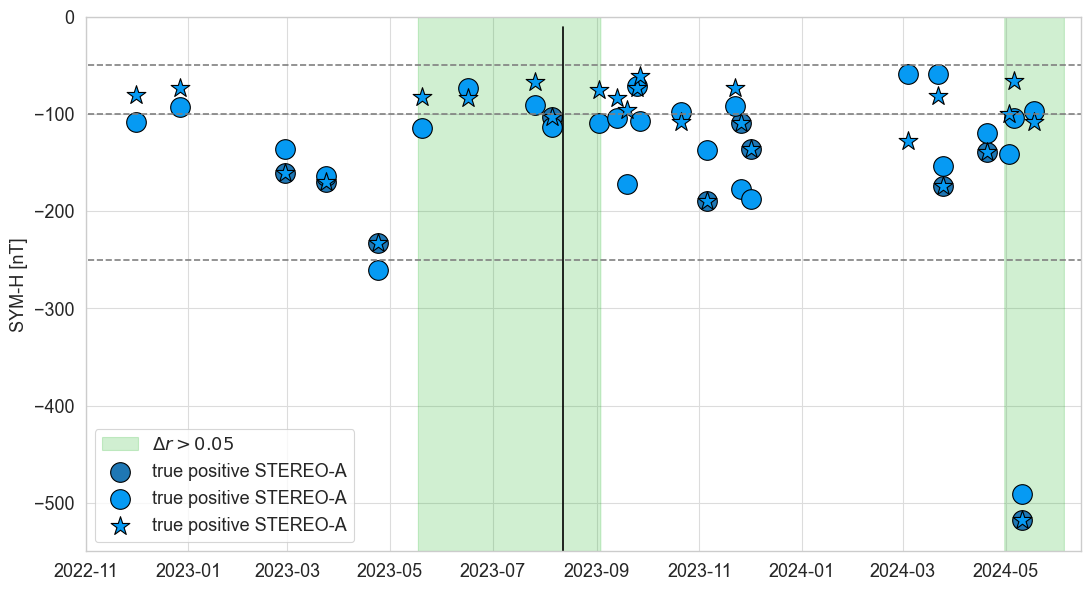

In [217]:
# for ESWW poster
plt.figure(1, figsize=(11,6), dpi=100)
plt.fill_between(sc_input.time, -550, 0, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$') 
plt.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-50,-50], color='gray', ls='--')
plt.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-100,-100], color='gray', ls='--')
plt.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-250,-250], color='gray', ls='--')
#plt.scatter(time_hit_omni_obs_l1 , symh_hit_omni_obs_l1 , marker='o', edgecolor='black', s=250, color=c2, alpha=0.7, label='true positive L1')
#plt.scatter(time_miss_omni_obs_l1 , symh_miss_omni_obs_l1 , marker='o', edgecolor='black', s=250, color=c0, alpha=0.7, label='false negative L1')
plt.scatter(time_intense_both, symh_intense_both, marker='o', s=200, color=None, edgecolor='black', label='true positive STEREO-A')
plt.scatter(time_hit_omni, symh_hit_sta, marker='o', s=200, color=c3, edgecolor='black', label='true positive STEREO-A')
plt.scatter(time_hit_omni, symh_hit_omni, marker='*', s=200, color=c3, edgecolor='black', label='true positive STEREO-A')
#plt.scatter(time_miss_omni, symh_miss_omni, marker='x', s=250, edgecolor='black', color='red', label='false negative STEREO-A')
plt.plot([datetime(2023,8,12),datetime(2023,8,12)], [-550,-10], 'k-')
plt.ylim(-550,0)
plt.xlim(datetime(2022,11,1), datetime(2024,6,15))
plt.ylabel('SYM-H [nT]',fontsize=13)
plt.tick_params('x', labelsize=13)
plt.tick_params('y', labelsize=13)
plt.legend(loc='lower left', fontsize=13)
plt.tight_layout()

#plt.savefig('hits_misses_esww_poster.pdf')

In [197]:
sc_input_heeq = pickle.load(open(data_path+'sta__HEEQ_20221111_20240614.p', 'rb'))


In [214]:
print(time_hit_omni_obs_l1, time_hit_omni)

[datetime.datetime(2022, 12, 7, 17, 39)
 datetime.datetime(2023, 1, 4, 9, 4) datetime.datetime(2023, 2, 10, 2, 46)
 datetime.datetime(2023, 2, 21, 12, 4)
 datetime.datetime(2023, 2, 27, 12, 13)
 datetime.datetime(2023, 3, 15, 22, 54)
 datetime.datetime(2023, 3, 24, 5, 22)
 datetime.datetime(2023, 4, 24, 4, 3) datetime.datetime(2023, 5, 6, 5, 32)
 datetime.datetime(2023, 5, 20, 7, 11)
 datetime.datetime(2023, 6, 16, 9, 32)
 datetime.datetime(2023, 7, 16, 23, 41)
 datetime.datetime(2023, 7, 26, 7, 54)
 datetime.datetime(2023, 8, 5, 5, 49)
 datetime.datetime(2023, 9, 2, 10, 20)
 datetime.datetime(2023, 9, 12, 22, 3)
 datetime.datetime(2023, 9, 19, 2, 50)
 datetime.datetime(2023, 9, 25, 2, 23)
 datetime.datetime(2023, 9, 26, 20, 12)
 datetime.datetime(2023, 10, 21, 7, 28)
 datetime.datetime(2023, 10, 29, 5, 20)
 datetime.datetime(2023, 11, 5, 16, 55)
 datetime.datetime(2023, 11, 22, 6, 43)
 datetime.datetime(2023, 11, 25, 19, 11)
 datetime.datetime(2023, 12, 1, 13, 30)
 datetime.datetime(2

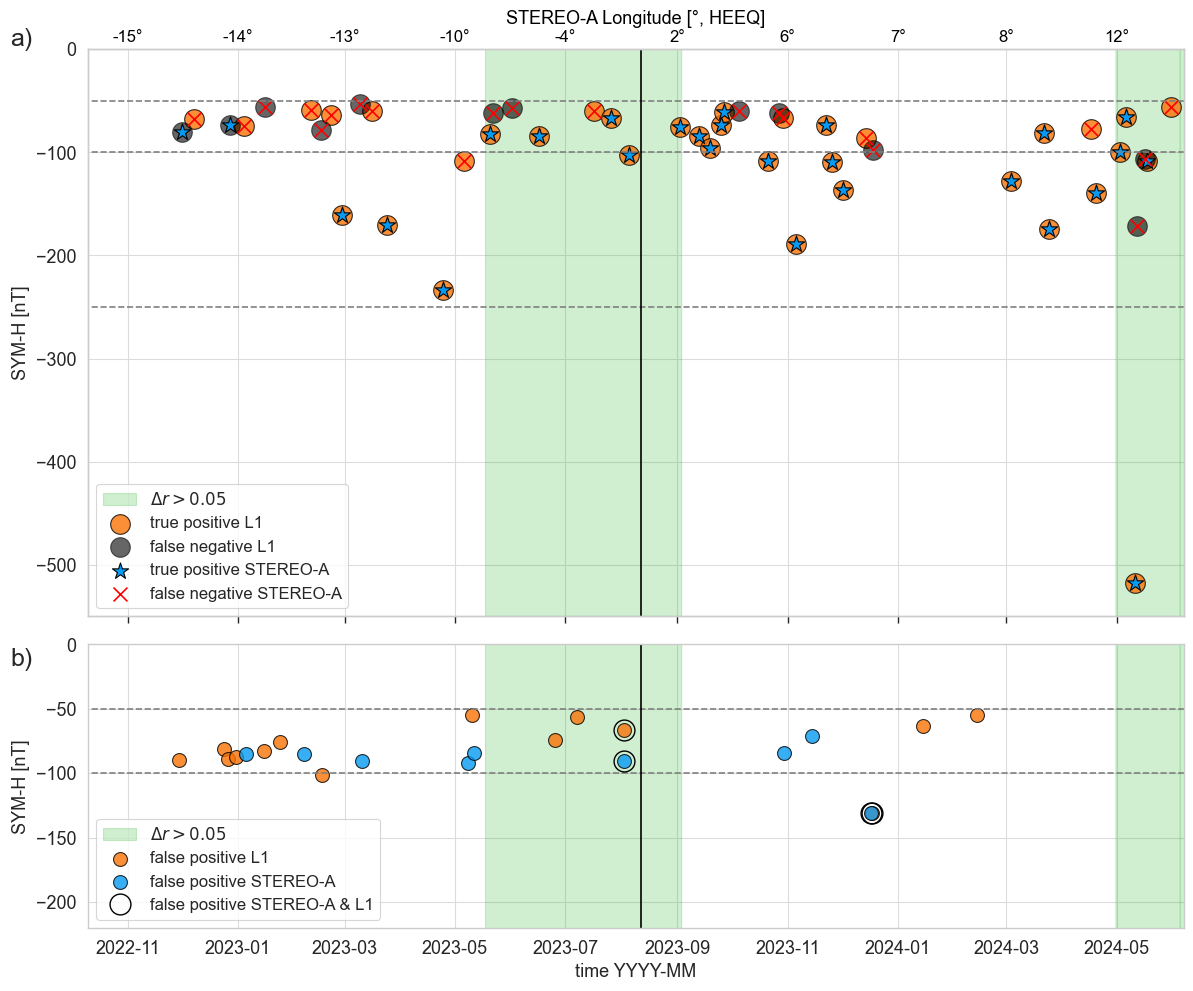

In [211]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(12,10), dpi=100, gridspec_kw={'height_ratios': [2, 1]})

#ax1.fill_between(sc_input.time, -550, 0, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$') 
#ax1.scatter(time_hit_omni_obs_l1 , symh_hit_omni_obs_l1 , marker='*', edgecolor='black', linewidth=0.8, s=500, color=c2, alpha=0.8, label='true positive L1')
#ax1.scatter(time_hit_omni, symh_hit_omni, marker='*', s=100, color=c3, edgecolor='black', label='true positive STEREO-A')
#ax1.plot(time_miss_omni_obs_l1 , symh_miss_omni_obs_l1 , marker='o', mfc='none', ms=18, color=c2, ls=' ', alpha=0.8, label='false negative L1')
#ax1.plot(time_miss_omni, symh_miss_omni, marker='x', ms=15, color='red', ls=' ', label='false negative STEREO-A')
#ax1.plot([datetime(2023,8,12),datetime(2023,8,12)], [-550,-10], 'k-')
#ax1.set_ylim(-550,-10)
#ax1.set_xlim(datetime(2022,11,1), datetime(2024,6,15))
#ax1.set_ylabel('SYM-H [nT]',fontsize=13)
#ax1.tick_params('x', labelsize=13)
#ax1.tick_params('y', labelsize=13)
#ax1.legend(loc='lower left', fontsize=13)

ax1.fill_between(sc_input_heeq.time, -550, 0, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$') 
ax1.fill_between([sc_input_heeq.time[-1], datetime(2024,6,15)], -550, 0, color=c4, alpha=0.2) 
ax1.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-50,-50], color='gray', ls='--')
ax1.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-100,-100], color='gray', ls='--')
#ax1.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-200,-200], color='gray', ls='--')
ax1.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-250,-250], color='gray', ls='--')
ax1.scatter(time_hit_omni_obs_l1 , symh_hit_omni_obs_l1 , marker='o', edgecolor='black', s=200, color=c2, alpha=0.8, label='true positive L1')
ax1.scatter(time_miss_omni_obs_l1 , symh_miss_omni_obs_l1 , marker='o', edgecolor='black', s=200, color=c0, alpha=0.6, label='false negative L1')
ax1.scatter(time_hit_omni, symh_hit_omni, marker='*', s=150, color=c3, edgecolor='black', label='true positive STEREO-A')
ax1.scatter(time_miss_omni, symh_miss_omni, marker='x', s=100, edgecolor='black', color='red', label='false negative STEREO-A')
ax1.plot([datetime(2023,8,12),datetime(2023,8,12)], [-550,0], 'k-')
ax1.set_ylim(-550,0)
ax1.set_xlim(datetime(2022,10,10), datetime(2024,6,7))
ax1.set_ylabel('SYM-H [nT]',fontsize=13)
ax1.tick_params('x', labelsize=13)
ax1.tick_params('y', labelsize=13)
ax1.legend(loc='lower left', fontsize=12)
t_float = date2num(sc_input.time)
ax3 = ax1.twiny()
ticks = ax1.get_xticks()
ax3.set_xticks(mdates.num2date(ticks))
ax3.grid(False)
lon_interp = np.interp(ticks, t_float, sc_input_heeq.lon)
ax3.set_xticklabels([f"{L:.0f}°" for L in lon_interp], color=c0, fontsize=12)
ax3.set_xlabel('STEREO-A Longitude [°, HEEQ]', color=c0,fontsize=13)  # we already handled the x-label with ax1
ax3.tick_params(axis='x', length=0)
ax3.set_xlim(ax1.get_xlim())

ax2.fill_between(sc_input.time, -550, 10, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$') 
ax2.fill_between([sc_input.time[-1], datetime(2024,6,15)], -550, 0, color=c4, alpha=0.2) 
#ax2.scatter(time_false_alarm_l1_all, symh_false_alarm_l1_all, marker='o', edgecolor='black', ms=8, color=c2, ls=' ', label='false positive L1')
#ax2.scatter(time_false_alarm, symh_false_alarm, marker='o', edgecolor='black', ms=8, color=c3, ls=' ', alpha=0.8, label='false positive STEREO-A')
ax2.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-50,-50], color='gray', ls='--')
ax2.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-100,-100], color='gray', ls='--')
#ax2.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-200,-200], color='gray', ls='--')
ax2.scatter(time_false_alarm_l1_all, symh_false_alarm_l1_all, marker='o', edgecolor='black', s=100, color=c2, alpha=0.8, label='false positive L1')
ax2.scatter(time_false_alarm, symh_false_alarm, marker='o', edgecolor='black', s=100, color=c3, alpha=0.8, label='false positive STEREO-A')
ax2.plot(time_false_alarm_sta_l1, symh_false_alarm_sta_l1, marker='o', mfc='none', ms=15, color=c0, ls=' ', label='false positive STEREO-A & L1') 
ax2.plot(time_false_alarm_l1_sta, symh_false_alarm_l1_sta, marker='o', mfc='none', ms=15, color=c0, ls=' ') 
ax2.plot([datetime(2023,8,12),datetime(2023,8,12)], [-550,10], 'k-')
ax2.set_ylim(-220,0)
ax2.set_xlabel('time YYYY-MM',fontsize=13)
ax2.set_ylabel('SYM-H [nT]',fontsize=13)
ax2.tick_params('x', labelsize=13)
ax2.tick_params('y', labelsize=13)
ax2.legend(loc='lower left', fontsize=12)

plt.figtext(0.01,0.95, 'a)', fontsize=18)
plt.figtext(0.01,0.33, 'b)', fontsize=18)
plt.tight_layout()
plt.savefig('hits_misses_false_alarms_beacon_plasma_444_corr.pdf')


-2.3858024691358026
-48.13888888888888
36
2022-12-07 16:51:00 0.8
2023-01-04 06:32:00 2.533333333333333
2023-02-10 02:57:00 -0.18333333333333332
2023-02-21 11:40:00 0.4
2023-02-27 11:10:00 1.05
2023-03-16 02:06:00 -3.2
2023-03-24 03:25:00 1.95
2023-04-24 06:24:00 -2.35
2023-05-06 06:40:00 -1.1333333333333333
2023-05-20 07:37:00 -0.43333333333333335
2023-06-16 12:41:00 -3.15
2023-07-17 10:29:00 -10.8
2023-07-26 08:51:00 -0.95
2023-08-05 06:13:00 -0.4
2023-09-02 21:13:00 -10.883333333333333
2023-09-12 20:39:00 1.4
2023-09-19 04:22:00 -1.5333333333333334
2023-09-25 01:46:00 0.6166666666666667
2023-09-26 11:57:00 8.25
2023-10-21 11:46:00 -4.3
2023-10-29 11:54:00 -6.566666666666666
2023-11-05 19:06:00 -2.183333333333333
2023-11-22 08:00:00 -1.2833333333333334
2023-11-25 19:31:00 -0.3333333333333333
2023-12-01 13:19:00 0.18333333333333332
2023-12-14 07:36:00 1.05
2024-03-03 19:15:00 -1.15
2024-03-21 21:30:00 -1.9
2024-03-24 18:01:00 -1.6666666666666667
2024-04-16 21:43:00 0.26666666666666666

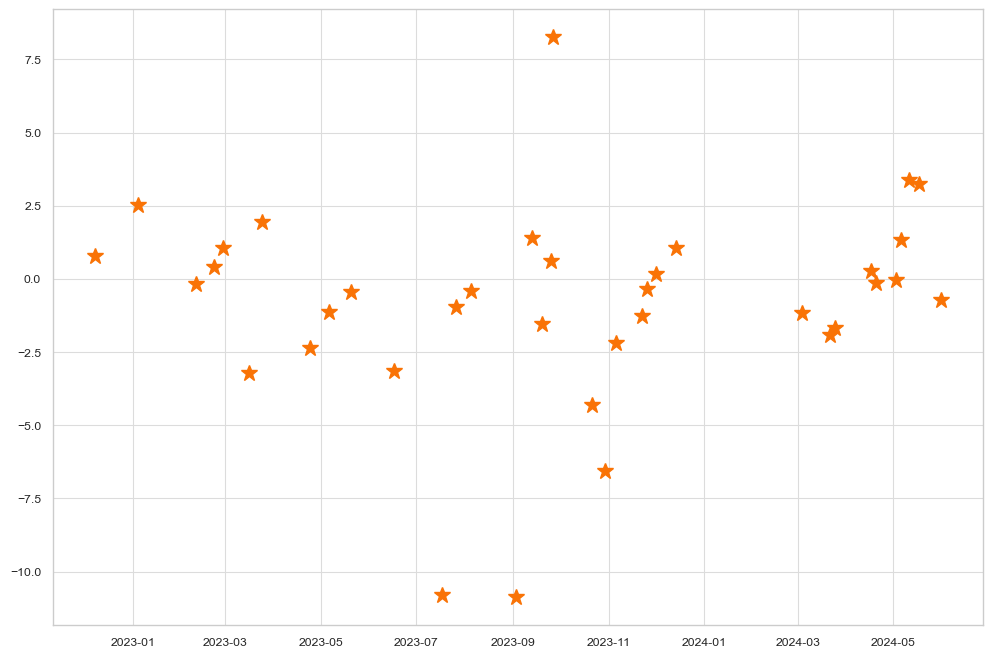

In [30]:
time_diff = np.array([(i-j).total_seconds()/3600. for i,j in zip(time_hit_omni, time_hit_sta)])
#time_diff = np.array([(i-j).total_seconds()/3600. for i,j in zip(time_hit_sta, time_hit_omni)])
#time_diff = np.array([(i-j).total_seconds()/3600. for i,j in zip(time_hit_l1, time_hit_sta)])
print(np.mean(time_diff))
symh_diff = symh_hit_sta-symh_hit_omni

time_diff_l1 = np.array([(i-j).total_seconds()/3600. for i,j in zip(time_hit_omni_obs_l1, time_hit_omni_l1)])
print(np.mean(time_diff_l1)*60.)
print(len(time_diff_l1))
symh_diff_l1 = symh_hit_omni_l1-symh_hit_omni_obs_l1

plt.figure(figsize=(12,8))
plt.plot(time_hit_omni_l1, time_diff_l1, marker='*', ms=12, color=c2, ls=' ')

for i in range(len(time_hit_omni_l1)):
    print(time_hit_omni_l1[i], time_diff_l1[i])

In [31]:
print('percentage of events predicted later than observed: ', np.round(len(time_diff[time_diff<0])/len(time_diff)*100,0))
print(time_diff)

print(time_hit_omni[np.abs(time_diff)==np.max(np.abs(time_diff))])
print(np.max(time_diff))

percentage of events predicted later than observed:  74.0
[-10.83333333   9.9         -6.58333333  -4.65        -7.48333333
  -2.28333333  19.35        -2.65        -7.16666667 -12.03333333
  -1.4        -13.41666667  -2.58333333  11.25         1.13333333
  -0.98333333  -4.46666667  -2.6         -7.1          2.1
  -5.73333333  -7.31666667  -9.53333333  -4.65         2.93333333
   3.03333333  -0.65      ]
[datetime.datetime(2023, 6, 16, 9, 32)]
19.35


In [39]:
print(min(abs(time_diff)), max(abs(time_diff)))
print(max(abs(time_diff)))
print(min(abs(symh_diff)), max(abs(symh_diff)))
print(' ')
#print(min(time_diff_l1), max(time_diff_l1))
#print(min(symh_diff_l1), max(symh_diff_l1))
print(' ')
print(14./len(time_diff)*100)

print(len(time_diff))

0.65 19.35
19.35
1.3151179566780797 76.01477847792279
 
 
51.85185185185185
27


In [34]:
time_hit_both_omni = omni_input.time[indices_both_omni]
time_hit_both_sta = data1['time'][indices_both_sta]
time_hit_both_l1 = data_l1['time'][indices_both_l1]

symh_hit_both_omni = omni_input.symh[indices_both_omni]
symh_hit_both_sta = data1['symh'][indices_both_sta]
symh_hit_both_l1 = data_l1['symh'][indices_both_l1]

time_diff_both = np.array([(i-j).total_seconds()/3600. for i,j in zip(time_hit_both_l1, time_hit_both_omni)])
time_diff_both_omni = np.array([(i-j).total_seconds()/3600. for i,j in zip(time_hit_both_sta, time_hit_both_omni)])
symh_diff_both = np.array([(i-j) for i,j in zip(symh_hit_both_l1, symh_hit_both_omni)])

In [35]:
print(3*data1['time_err'])

better_l1 = time_hit_both_omni[abs(time_diff_both_omni)>abs(time_diff_both)]
#print(time_hit_both_omni)
#print(time_miss_omni_obs_l1)
#print(better_l1)
print(len(better_l1))

worse_l1 = time_hit_both_omni[abs(time_diff_both_omni)<abs(time_diff_both)]
#print(worse_l1)
print(len(worse_l1))

[6.62518001 6.62514997 6.62511921 ... 7.21305084 7.21308446 7.21311736]
20
4


In [36]:
#print(len(time_hit_omni))
#print(time_miss_omni)
print('STEREO-A')
print(len(time_hit_omni[time_hit_omni>datetime(2023,8,12)]))
print(len(time_hit_omni[time_hit_omni<datetime(2023,8,12)]))
print(len(time_miss_omni[time_miss_omni>datetime(2023,8,12)]))
print(len(time_miss_omni[time_miss_omni<datetime(2023,8,12)]))

print('TPR west: ', np.round(len(time_hit_omni[time_hit_omni>datetime(2023,8,12)])/len(time_hit_omni)*100,0))
print('TPR east: ', np.round(len(time_hit_omni[time_hit_omni<datetime(2023,8,12)])/len(time_hit_omni)*100,0))
print('FNR west:', np.round(len(time_miss_omni[time_miss_omni>datetime(2023,8,12)])/len(time_miss_omni)*100,0))
print('FNR east:', np.round(len(time_miss_omni[time_miss_omni<datetime(2023,8,12)])/len(time_miss_omni)*100,0))
print('FPR west:', np.round(100-len(time_false_alarm[time_false_alarm>datetime(2023,8,12)])/len(time_false_alarm)*100,0))


print('L1')
print(len(time_hit_omni_obs_l1[time_hit_omni_obs_l1>datetime(2023,8,12)]))
print(len(time_hit_omni_obs_l1[time_hit_omni_obs_l1<datetime(2023,8,12)]))
print(len(time_miss_omni_obs_l1[time_miss_omni_obs_l1>datetime(2023,8,12)]))
print(len(time_miss_omni_obs_l1[time_miss_omni_obs_l1<datetime(2023,8,12)]))


print('TPR west: ', np.round(len(time_hit_omni_obs_l1[time_hit_omni_obs_l1>datetime(2023,8,12)])/len(time_hit_omni_obs_l1)*100,0))
print('TPR east: ', np.round(len(time_hit_omni_obs_l1[time_hit_omni_obs_l1<datetime(2023,8,12)])/len(time_hit_omni_obs_l1)*100,0))
print('FNR west:', np.round(len(time_miss_omni_obs_l1[time_miss_omni_obs_l1>datetime(2023,8,12)])/len(time_miss_omni_obs_l1)*100,0))
print('FNR east:', np.round(len(time_miss_omni_obs_l1[time_miss_omni_obs_l1<datetime(2023,8,12)])/len(time_miss_omni_obs_l1)*100,0))
print('FPR west:', np.round(100-len(time_false_alarm_l1_all[time_false_alarm_l1_all>datetime(2023,8,12)])/len(time_false_alarm_l1_all)*100,0))

STEREO-A
18
9
9
12
TPR west:  67.0
TPR east:  33.0
FNR west: 43.0
FNR east: 57.0
FPR west: 67.0
L1
22
14
5
7
TPR west:  61.0
TPR east:  39.0
FNR west: 42.0
FNR east: 58.0
FPR west: 79.0


In [37]:
for i in range(len(time_hit_omni)):
    print(time_hit_omni[i], round(-time_diff[i],1), '&', round(symh_diff[i],1))

2022-11-30 19:19:00 10.8 & -27.8
2022-12-27 08:11:00 -9.9 & -19.9
2023-02-27 12:13:00 6.6 & 24.6
2023-03-24 05:22:00 4.6 & 6.1
2023-04-24 04:03:00 7.5 & -27.3
2023-05-20 07:11:00 2.3 & -32.0
2023-06-16 09:32:00 -19.4 & 10.6
2023-07-26 07:54:00 2.6 & -24.1
2023-08-05 05:49:00 7.2 & -10.5
2023-09-02 10:20:00 12.0 & -34.3
2023-09-12 22:03:00 1.4 & -20.1
2023-09-19 02:50:00 13.4 & -76.0
2023-09-25 02:23:00 2.6 & 1.3
2023-09-26 20:12:00 -11.2 & -46.1
2023-10-21 07:28:00 -1.1 & 9.7
2023-11-05 16:55:00 1.0 & 51.7
2023-11-22 06:43:00 4.5 & -18.3
2023-11-25 19:11:00 2.6 & -68.6
2023-12-01 13:30:00 7.1 & -51.9
2024-03-03 18:06:00 -2.1 & 69.0
2024-03-21 19:36:00 5.7 & 21.7
2024-03-24 16:21:00 7.3 & 20.6
2024-04-19 19:21:00 9.5 & 19.1
2024-05-02 19:43:00 4.6 & -41.5
2024-05-06 01:13:00 -2.9 & -38.6
2024-05-11 02:14:00 -3.0 & 27.4
2024-05-17 23:05:00 0.6 & 10.7


-2.4 -48.1
-9.8 -2.0


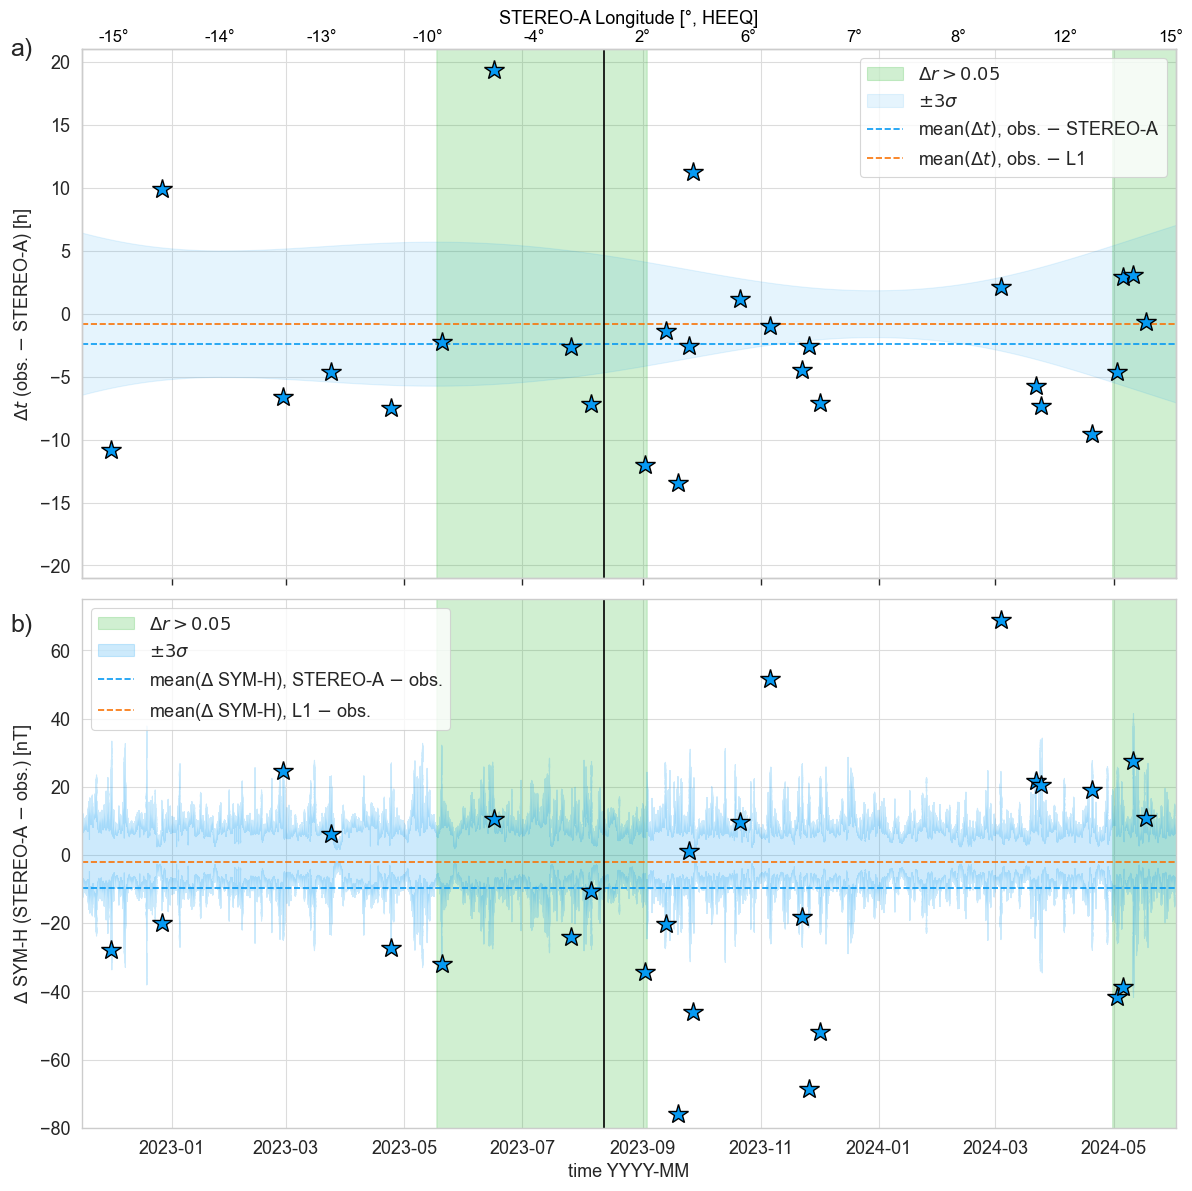

In [44]:
print(round(np.mean(time_diff),1), round(np.mean(time_diff_l1)*60.,1))
print(round(np.mean(symh_diff),1), round(np.mean(symh_diff_l1),1))

fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(12,12), dpi=100, gridspec_kw={'height_ratios': [1, 1]})

#ax1.fill_betweenx([-20,20], [data1['time'][index_time0],data1['time'][index_time0]], [data1['time'][index_time1],data1['time'][index_time1]], color=c4, alpha=0.2, label=r'$\Delta r > 0.04$ au')
#ax1.fill_betweenx([-20,20], [data1['time'][index_time10],data1['time'][index_time10]], [data1['time'][index_time11],data1['time'][index_time11]], color=c4, alpha=0.2)
ax1.fill_between(sc_input.time, -200, 200, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$') 
ax1.fill_between(data1['time'], 3*data1['time_err'], -3*data1['time_err'], color=c3, alpha=0.1, label=r'$\pm 3 \sigma$')
ax1.plot([time_hit_omni[0]-timedelta(days=15), time_hit_omni[-1]+timedelta(days=15)], [np.mean(time_diff),np.mean(time_diff)], color=c3, ls='--', label=r'mean$(\Delta t)$, obs. $-$ STEREO-A')
ax1.plot([time_hit_omni[0]-timedelta(days=15), time_hit_omni[-1]+timedelta(days=15)], [np.mean(time_diff_l1),np.mean(time_diff_l1)], color=c2, ls='--', label=r'mean$(\Delta t)$, obs. $-$ L1')
ax1.plot(time_hit_omni, time_diff, marker='*', color=c3, mec='black', ms=15, ls=' ')
#ax1.plot(time_hit_both_omni, time_diff_both, marker='o', ms=8, color=c2, ls=' ', label=r'$\Delta t$ (L1 $-$ STEREO-A)')

#ax1.plot(data1['time'], -3*data1['time_err'], color=c0, ls='--', alpha=0.5)
ax1.plot([datetime(2023,8,12),datetime(2023,8,12)], [-200,200], 'k-')
ax1.set_ylim(-21,21)
ax1.set_ylabel(r'$\Delta t$ (obs. $-$ STEREO-A) [h]',fontsize=13)
ax1.legend(loc='upper right', fontsize=13)
ax1.tick_params('y', labelsize=13)
ax3 = ax1.twiny()
ticks = ax1.get_xticks()
ax3.set_xticks(mdates.num2date(ticks))
ax3.grid(False)
t_float = mdates.date2num(sc_input_heeq.time)
lon_interp = np.interp(ticks, t_float, sc_input_heeq.lon)
ax3.set_xticklabels([f"{L:.0f}°" for L in lon_interp], color=c0, fontsize=12)
ax3.set_xlabel('STEREO-A Longitude [°, HEEQ]', color=c0,fontsize=13)  # we already handled the x-label with ax1
ax3.tick_params(axis='x', length=0)
ax3.set_xlim(ax1.get_xlim())
#ax1.xlim(time_hit_omni[0]-timedelta(days=15), time_hit_omni[-1]+timedelta(days=15))

ax2.fill_between(sc_input.time, -90, 90, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$')
ax2.fill_between(data1['time'], 3*data1['symh_err'], -3*data1['symh_err'], color=c3, alpha=0.2, label=r'$\pm 3 \sigma$')
ax2.plot([time_hit_omni[0]-timedelta(days=15), time_hit_omni[-1]+timedelta(days=15)], [np.mean(symh_diff),np.mean(symh_diff)], color=c3, ls='--', label=r'mean($\Delta$ SYM-H), STEREO-A $-$ obs.')
ax2.plot([time_hit_omni[0]-timedelta(days=15), time_hit_omni[-1]+timedelta(days=15)], [np.mean(symh_diff_l1),np.mean(symh_diff_l1)], color=c2, ls='--', label=r'mean($\Delta$ SYM-H), L1 $-$ obs.')
ax2.plot(time_hit_omni, symh_diff, marker='*', ms=15, color=c3, mec='black', ls=' ')
#ax2.plot(time_hit_both_omni, symh_diff_both, marker='o', ms=8, color=c2, ls=' ', label=r'$\Delta$ SYM-H (L1 $-$ STEREO-A)')
ax2.plot([datetime(2023,8,12),datetime(2023,8,12)], [-100,200], 'k-')
ax2.set_xlim(time_hit_omni[0]-timedelta(days=15), time_hit_omni[-1]+timedelta(days=15))
ax2.set_ylim(-80,75)
ax2.set_xlabel('time YYYY-MM',fontsize=13)
ax2.set_ylabel(r'$\Delta$ SYM-H (STEREO-A $-$ obs.) [nT]',fontsize=13)
ax2.legend(loc='upper left', fontsize=13)
ax2.tick_params('x', labelsize=13)
ax2.tick_params('y', labelsize=13)
plt.figtext(0.01,0.95, 'a)', fontsize=18)
plt.figtext(0.01,0.47, 'b)', fontsize=18)
plt.tight_layout()
plt.savefig('diff_time_symh.pdf')

NameError: name 'index_time0' is not defined

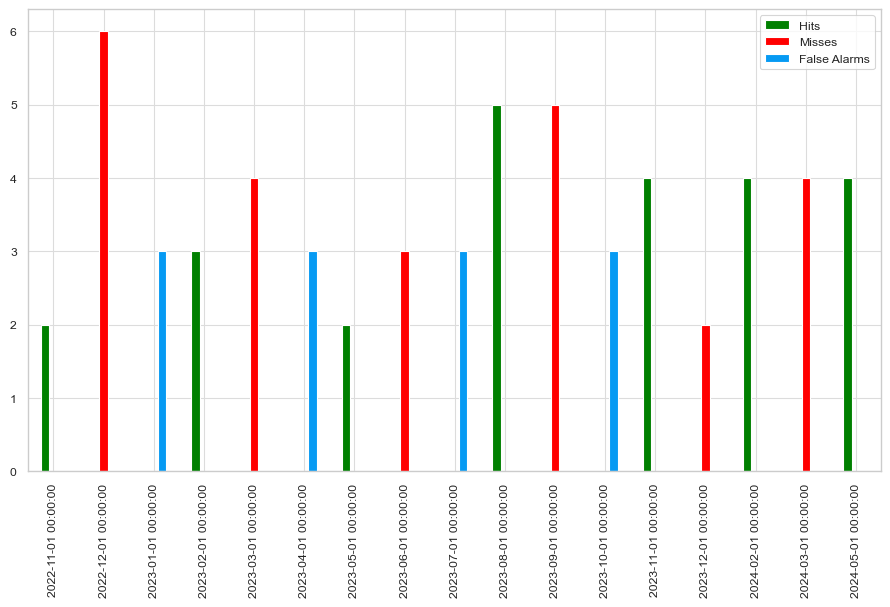

In [85]:
# Turn both into Series
hits = pd.Series([k for k in time_hit_omni])
misses = pd.Series([dt for dt in time_miss_omni])
false = pd.Series([dt for dt in time_false_alarm])

# Convert to datetime index
hit_counts = hits.value_counts().sort_index()
hit_counts.index = pd.to_datetime(hit_counts.index)

miss_counts = misses.value_counts().sort_index()
miss_counts.index = pd.to_datetime(miss_counts.index)

false_counts = false.value_counts().sort_index()
false_counts.index = pd.to_datetime(false_counts.index)

# Resample into 2-month bins (anchored at start of Jan, Mar, May, ...)
hit_binned = hit_counts.resample("3MS").sum()
miss_binned = miss_counts.resample("3MS").sum()
false_binned = false_counts.resample("3MS").sum()

# Combine into one DataFrame
df = pd.DataFrame({"Hits": hit_binned, "Misses": miss_binned, "False Alarms": false_binned}).fillna(0)

# --- Make custom labels ---
labels = []
for d in df.index:
    start_month = d.strftime("%b")       # Jan, Mar, May, ...
    end_month = (d + pd.DateOffset(months=1)).strftime("%b")  # next month
    year = d.strftime("%Y")
    labels.append(f"{start_month}–{end_month} {year}")

# --- Plot with custom labels ---
#fig, ax = plt.subplots(figsize=(10,10))

ax = df.plot(kind="bar", color=["green", "red", c3], figsize=(11,6))

ax.fill_betweenx([0,7], [data1['time'][index_time0],data1['time'][index_time0]], [data1['time'][index_time1],data1['time'][index_time1]], color=c4, alpha=0.2, label=r'$\Delta r > 0.04$ au')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.tick_params('y', labelsize=11)

#ax.set_xlabel("2-Month Interval", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
#ax.set_title("2-Month Peaks: Hits vs Misses", fontsize=14)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
#plt.savefig('hits_misses_false_alarms_bar_plot_beacon_plasma.png')

In [170]:
plot_monthly = False

if plot_monthly:
    # Count per month
    hit_counts = hits.groupby(hits.dt.to_period("M")).size()
    miss_counts = misses.groupby(misses.dt.to_period("M")).size()
    false_alarm_counts = false_alarms.groupby(false_alarms.dt.to_period("M")).size()

    # Reindex so both cover the same full range
    all_months = pd.period_range(omni_df['time'].min().to_period("M"), dates.max().to_period("M"), freq="M")
    hit_counts = hit_counts.reindex(all_months, fill_value=0)
    miss_counts = miss_counts.reindex(all_months, fill_value=0)
    false_alarm_counts = false_alarm_counts.reindex(all_months, fill_value=0)

    # Combine into one DataFrame
    df = pd.DataFrame({"Hits": hit_counts, "Misses": miss_counts, "False Alarms": false_alarm_counts})

    # Plot side by side bars
    df.plot(kind="bar", rot=45, ylabel="Count", title="Monthly Peaks: Hits vs Misses")
    plt.tight_layout()
    plt.show()

In [76]:
def make_frame(k, make_movie=False):
    '''
    loop each frame in multiprocessing
    '''
    

    fig=plt.figure(1, figsize=(19.2,10.8), dpi=100) #full hd
    #fig = plt.figure(figsize=(15,10), dpi=100)
    
    # Grid: 3 rows, 3 columns, with specific placement
    gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1, 0.05, 2], width_ratios=[20, 0.3, 2], hspace=0.01, wspace=0.05)

    # Top density (time KDE)
    ax0 = fig.add_subplot(gs[0, :2])

    # Bottom SYM-H time series
    ax1 = fig.add_subplot(gs[2, :2])

    # Right SYM-H KDE
    ax2 = fig.add_subplot(gs[2, -1], sharey=ax1)
    
    
    #fig=plt.figure(1, figsize=(19.2*2,10.8*2), dpi=100) #4k


    frame_time_str=str(mdates.num2date(frame_time_num+k*res_in_days))
    
    time_now=frame_time_num+k*res_in_days
    time_now_date = t_start + timedelta(days=k*res_in_days)
    
    #print(index)
    

    
    #ensemble_at_time_now = time_ensemble[index]
    #error_time = (ensemble_at_time_now-np.median(ensemble_at_time_now))/24./3600

    #print(mdates.num2date(time_now+error_time))
    
    #------------------------------------------------ IN SITU DATA ------------------------------------------------------
  
    #cut data for plot window so faster
    
    if data1['time'][-1] > time_now_date+timedelta(days=days_window):
        dindex1=np.where(data1['time'] > time_now_date-timedelta(days=days_window))[0][0]
        dindex2=np.where(data1['time'] > time_now_date+timedelta(days=days_window))[0][0]
        #use last index   oindex2=np.size(o1)-1
        data=data1[dindex1:dindex2] 
        
    if data_l1['time'][-1] > time_now_date+timedelta(days=days_window):
        lindex1=np.where(data_l1['time'] > time_now_date-timedelta(days=days_window))[0][0]
        lindex2=np.where(data_l1['time'] > time_now_date+timedelta(days=days_window))[0][0]
        #use last index   oindex2=np.size(o1)-1
        l1=data_l1[lindex1:lindex2] 
        
    if omni_input['time'][-1] > time_now_date+timedelta(days=days_window):
        oindex1=np.where(omni_input['time'] > time_now_date-timedelta(days=days_window))[0][0]
        oindex2=np.where(omni_input['time'] > time_now_date+timedelta(days=days_window))[0][0]
        #use last index   oindex2=np.size(o1)-1
        omni=omni_input[oindex1:oindex2] 
        
    index = np.where(data['time']==time_now_date)[0][0]
    current_symh = data['symh'][index]
        
    days_dist = 2
    
    # Compute KDE manually
    std = data['time_err'][index]
    x_vals = np.linspace(-3*std,3*std,100)
    y_vals = norm(loc=time_now, scale=std/24.).pdf(time_now+x_vals/24.)
    #y_fin = y/np.nanmax(y,axis=0)
    
    #kde = gaussian_kde(time_now+error_time)
    #x_vals = np.linspace(time_now - days_window, time_now + days_window, 500)
    #y_vals = kde(x_vals)

    # Normalize to max = 1
    y_vals /= np.nanmax(y_vals)
    
    

    #with sns.axes_style('white', {'axes.edgecolor': 'none'}):
    #ax0 = plt.subplot2grid((3,1), (0,0))
    #sns.kdeplot(time_now+error_time, ax=ax0,  color=c3, linewidth=2, fill=True)
    ax0.fill_between(time_now+x_vals/24., y_vals, color=c3, alpha=0.6)
    ax0.plot(time_now+x_vals/24., y_vals, color=c3, linewidth=2)
    ax0.plot_date([time_now,time_now], [0,2],'--', lw=1., alpha=0.9, color=c0)


    ax0.set_xlim(time_now-days_window,time_now+days_window)
    ax0.set_ylim(0.01,1.01)
    ax0.set_xticklabels([])
    ax0.set_yticklabels([])
    plt.tick_params( axis='x', labelbottom='off')
    #plt.yticks(fontsize=fsize-1)

    
    if np.size(data)>0:
        
        #ax1 = plt.subplot2grid((3,1), (1,0), rowspan=2)
        #ax1.set_ylim(np.min(data['symh'])-20, np.max(data['symh'])+20)
        #ax1.set_xlabel('time [YYYY-Month-DD]', fontsize=16)
        ax1.set_ylabel('SYM-H [nT]', fontsize=22)
        ax1.set_xlim(time_now-days_window,time_now+days_window)
        ax1.xaxis.set_major_formatter( matplotlib.dates.DateFormatter('%Y-%b-%d') )
        ax1.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
        ax1.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(days_dist/6))
        ax1.tick_params(axis='x', labelsize=20)
        ax1.tick_params(axis='y', labelsize=18)

        for i in range(len(times_earth_start)):
            ax1.fill_betweenx([-1000,200], times_earth_start[i], times_earth_end[i], color=c2, alpha=0.1)
            ax1.plot_date([times_earth_start[i],times_earth_start[i]], [-1000,200], '-', color=c2, lw=.8, alpha=.6)
            ax1.plot_date([times_earth_end[i],times_earth_end[i]], [-1000,200], '-', color=c2, lw=.8, alpha=.6)
            
        #for i in range(len(ic)):
         #   ax1.fill_betweenx([-1000,200], ic.icme_start_time.iloc[i], ic.mo_end_time.iloc[i], color=c2, alpha=0.1)
          #  ax1.plot_date([ic.icme_start_time.iloc[i],ic.icme_start_time.iloc[i]], [-1000,200], '-', color=c2, lw=.8, alpha=.6)
           # ax1.plot_date([ic.mo_end_time.iloc[i],ic.mo_end_time.iloc[i]], [-1000,200], '-', color=c2, lw=.8, alpha=.6)
        
        ax1.plot_date(omni['time'],omni['symh'],'-',c=c0,label='SYM-H obs.',linewidth=1)
        ax1.plot_date(l1['time'],l1['symh'],'-',c=c2,label='SYM-H L1',linewidth=1)
        ax1.plot_date(data['time'],data['symh'],'-',c=c3,label='SYM-H STEREO-A',linewidth=1)
        
        ax1.plot_date([time_now-days_window,time_now+days_window], [current_symh,current_symh],'--k', lw=1., alpha=0.6)
        ax1.plot_date([time_now,time_now], [-600,100],'--k', lw=1., alpha=0.6)
        
       
        ax1.plot(time_false_alarm_l1_all, symh_false_alarm_l1_all, marker='o', mec=c0, ms=8, color=c2, ls=' ')
        ax1.plot(time_miss_omni_obs_l1, symh_miss_omni_obs_l1,  marker='o', mfc='none', ms=18, color=c0, ls=' ')
        ax1.plot(time_hit_omni_l1, symh_hit_omni_l1, marker='*', ms=18,  mec=c0, color=c2, ls=' ')
        
        ax1.plot(time_false_alarm, symh_false_alarm, marker='o', ms=8, mec=c0, color=c3, ls=' ')
        ax1.plot(time_hit_omni, symh_hit_omni, marker='o', ms=8, mec=c0, color=c0, ls=' ')
        ax1.plot(time_miss_omni, symh_miss_omni, marker='x', ms=15, color='red', ls=' ')
        ax1.plot(time_hit_sta, symh_hit_sta, marker='*', ms=18,  mec=c0, color=c3, ls=' ')
        
        ax1.plot(time_false_alarm_sta_l1, symh_false_alarm_sta_l1, marker='o', mfc='none', ms=13, color=c0, ls=' ') 
        ax1.plot(time_false_alarm_l1_sta, symh_false_alarm_l1_sta, marker='o', mfc='none', ms=13, color=c0, ls=' ') 
        
        ax1.legend(loc='lower right', fontsize=20)
        
        if np.min(omni.symh) < np.min(data['symh']) and  np.min(omni.symh) < np.min(l1['symh']):
            ax1.set_ylim(np.min(omni['symh'])-10,np.max(omni['symh'])+10)
        elif np.min(l1.symh) < np.min(data['symh']) and  np.min(l1.symh) < np.min(omni.symh):
            ax1.set_ylim(np.min(l1['symh'])-10,np.max(omni['symh'])+10)
        elif np.min(data['symh']) < np.min(l1.symh) and  np.min(data['symh']) < np.min(omni.symh):
            ax1.set_ylim(np.min(data['symh'])-10,np.max(omni['symh'])+10)
        
        
     # === 3. SYM-H KDE (right-side panel) ===
    std_symh = data['symh_err'][index]
    x_vals_symh = np.linspace(-3*std_symh,3*std_symh,100)
    y_vals_symh = norm(loc=current_symh, scale=std_symh).pdf(current_symh+x_vals_symh)
    y_vals_symh /= np.nanmax(y_vals_symh, axis=0)
    
    #kde_symh = gaussian_kde(symh_ensemble[index])
    #y_vals_symh = np.linspace(np.min(symh_ensemble[index]), np.max(symh_ensemble[index]), 250)
    #x_vals_symh = kde_symh(y_vals_symh)
    #x_vals_symh /= np.max(x_vals_symh)  # normalize
    
    ax2.plot_date([0,1.01], [current_symh,current_symh],'--k', lw=1., alpha=0.6)
                
    ax2.fill_betweenx(current_symh+x_vals_symh, y_vals_symh, color=c3, alpha=0.6)
    ax2.plot(y_vals_symh, current_symh+x_vals_symh, color=c3, linewidth=2)
    ax2.set_xlim(0.01, 1.01)
    ax2.set_xticklabels([])
    ax2.tick_params(labelleft=False, left=False)
    #ax2.tick_params(axis='y', labelsize=13)
    #ax2.set_yticklabels([])
    #ax2.set_xlabel('Density', fontsize=fsize-1)
    #ax2.tick_params(axis='x', labelsize=fsize-2)
    
    x_pos_text=0.4
    y_pos_text=0.9
    
    plt.figtext(x_pos_text, y_pos_text, frame_time_str[0:4], ha='left', color=c0, fontsize=fsize+6)
    
    plt.figtext(x_pos_text+0.038, y_pos_text, frame_time_str[5:7], ha='left', color=c0, fontsize=fsize+6)
    
    plt.figtext(x_pos_text+0.06, y_pos_text, frame_time_str[8:10], ha='left', color=c0, fontsize=fsize+6)
    
    plt.figtext(x_pos_text+0.09, y_pos_text, frame_time_str[11:13], ha='left', color=c0, fontsize=fsize+6)
    
    plt.figtext(x_pos_text+0.13, y_pos_text, 'UTC', ha='center', color=c0, fontsize=fsize+6)
    
    
    plt.tight_layout()
    
    #plt.show()
    
    if make_movie:
        
        #save figure
        framestr = '%05i' % (k)
        filename='figures/frames/pos_anim_'+str(count)+'.jpg'  
        #if k==0: print(filename)
        plt.savefig(filename,dpi=200,facecolor=fig.get_facecolor(), edgecolor='none')
        #plt.clf()
        #if close==True: plt.close('all')

        plt.close('all')
        
    else:
        plt.show()


    ########################################### loop end'



In [77]:
plt.close('all')

print('Define settings')

count = 0
format_str = '%Y-%m-%d'  
format_str_minutes = '%Y-%m-%d %H:%M'
date_today_hour = datetime.now().strftime(format_str)

#outputdirectory='output/frames'#+str(date_today_hour)
#animdirectory='output/'
t_start = data1['time'][0]
t_end  = data1['time'][-1]
print(t_start)
#res_in_days=1/72. #every 20min
#res_in_days=1/144. #every 10min
#res_in_days=1/1440. # every minute
res_in_days=1/24. #every hour
#res_in_days=1/48. #every 30min


#make time range to see how much frames are needed 
starttime = t_start #parse_time(t_start)
endtime = t_end #parse_time(t_end)
alltimes = []
while starttime < endtime:
    alltimes.append(starttime)
    starttime += timedelta(days=res_in_days)
k_all=np.size(alltimes)

print('# of frames: ', k_all)

#print(date_today_hour)
days_window=4    #size of in situ timerange

#if os.path.isdir(outputdirectory) == False: os.mkdir(outputdirectory)
#if os.path.isdir(animdirectory) == False: os.mkdir(animdirectory)

print('done')

#positions_plot_directory='results/plots_positions/'
#if os.path.isdir(positions_plot_directory) == False: os.mkdir(positions_plot_directory)

#print(k_all)

#print('done')
#print(mdates.num2date(hc_time_num1))


Define settings
2022-11-11 10:08:00
# of frames:  13728
done


In [79]:

print('Save kinematics plots and overview plot for current time')

#%matplotlib inline

start_time=time.time()

#print()
#print('make animation')

#animation start time in matplotlib format

frame_time_num=mdates.date2num(t_start)#parse_time(t_start).plot_date
#frame_time = datetime(2024,3,17,10)

frame_time_num_list = [frame_time_num+k*res_in_days for k in range(k_all)]

dct_hit = [mdates.date2num(time_hit_sta[i])-frame_time_num_list for i in range(len(time_hit_sta))]

k_hit=[]

for i in dct_hit:
    k_hit.append(np.argmin(np.abs(i)))

    
dct_miss = [mdates.date2num(time_miss_omni[i])-frame_time_num_list for i in range(len(time_miss_omni))]

k_miss=[]

for i in dct_miss:
    k_miss.append(np.argmin(np.abs(i)))
    

dct_fa = [mdates.date2num(time_false_alarm[i])-frame_time_num_list for i in range(len(time_false_alarm))]

k_fa=[]

for i in dct_fa:
    k_fa.append(np.argmin(np.abs(i)))

#frame_index = np.where(frame_time_num_list==mdates.date2num(datetime(2024,3,18,16,0)))[0][0]#

fsize=13


#for parker spiral   
theta=np.arange(0,np.deg2rad(180),0.01)

######################## make frames

#for debugging
#don't close plot in make_frame when testing

#plot_kinematics(hc_time_num1, hc_r1, hc_v1)
####################### plot and save frame with todays date and hour 
#make_frame3(k_today[0][0]) 

####################### test animation frames (different frame numbers)
#make_frame2(frame_index)#k_today[0][0])
make_movie=False
make_frame(k_hit[5])#k_today[0][0]) #6000

count=0
#for i in k_miss:
#    count+=1
#    make_frame(i, make_movie=True)

print('done') #



Save kinematics plots and overview plot for current time
done


In [71]:
make_movie=True
if make_movie:
    
    import multiprocessing
    import multiprocess as mp
    matplotlib.use('Agg')

    print('Creating ', k_all,' frames')

    print()

    start_time=time.time()

    #number of processes depends on your machines memory; check with command line "top"
    #how much memory is used by all your processesii
    nr_of_processes_used=3
    print('Using multiprocessing, nr of cores',multiprocessing.cpu_count(), \
          'with nr of processes used: ',nr_of_processes_used)

    #run multiprocessing pool to make all movie frames, depending only on frame number

    pool=mp.get_context('fork').Pool(processes=nr_of_processes_used)

    #pool = mp.Pool(processes=nr_of_processes_used)
    #input=[i for i in range(k_all)]
    input=[i for i in np.arange(1,k_all,1)]
    pool.map(make_frame, input)
    pool.close()
    pool.join()
    #for i in input:
     #   make_frame2(i)

    print('time in min: ',np.round((time.time()-start_time)/60))
    print('plots done, frames saved')


Creating  13728  frames

Using multiprocessing, nr of cores 8 with nr of processes used:  3


Process ForkPoolWorker-2:
Process ForkPoolWorker-3:
Traceback (most recent call last):
Process ForkPoolWorker-1:
Traceback (most recent call last):
  File "/Users/eva/anaconda3/envs/helio4/lib/python3.10/site-packages/multiprocess/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/Users/eva/anaconda3/envs/helio4/lib/python3.10/site-packages/multiprocess/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/eva/anaconda3/envs/helio4/lib/python3.10/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/eva/anaconda3/envs/helio4/lib/python3.10/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/eva/anaconda3/envs/helio4/lib/python3.10/site-packages/multiprocess/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/eva/anaconda3/envs/helio4/lib/python3.10/site-packages/multiprocess/process.py"

KeyboardInterrupt: 

  File "/Users/eva/anaconda3/envs/helio4/lib/python3.10/site-packages/multiprocess/pool.py", line 48, in mapstar
    return list(map(*args))
  File "/Users/eva/anaconda3/envs/helio4/lib/python3.10/site-packages/multiprocess/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/var/folders/gk/h721n16n74d75yqq7dkvnr0c0000gn/T/ipykernel_80917/352648917.py", line 122, in make_frame
    ax1.plot_date(l1['time'],l1['symh'],'-',c=c2,label='SYM-H L1',linewidth=1)
  File "/var/folders/gk/h721n16n74d75yqq7dkvnr0c0000gn/T/ipykernel_80917/352648917.py", line 122, in make_frame
    ax1.plot_date(l1['time'],l1['symh'],'-',c=c2,label='SYM-H L1',linewidth=1)
  File "/Users/eva/anaconda3/envs/helio4/lib/python3.10/site-packages/multiprocess/pool.py", line 48, in mapstar
    return list(map(*args))
  File "/var/folders/gk/h721n16n74d75yqq7dkvnr0c0000gn/T/ipykernel_80917/352648917.py", line 51, in make_frame
    lindex1=np.where(data_l1['time'] > time_now_date-timedelta(days=day

In [269]:
ffmpeg_path=''

os.system(ffmpeg_path+'ffmpeg -r 20 -i figures/frames/pos_anim_%05d.jpg -b 5000k \
    -r 20 figures/frames/symh_forecast.mp4 -y -loglevel warning') 

print('movie done & saved')

Please use -b:a or -b:v, -b is ambiguous


movie done & saved
